In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from tqdm import tqdm
from torch.utils.data import Dataset
from pathlib import Path
from PIL import Image
from torchvision import transforms as T
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
import zipfile
from pathlib import Path

LOCAL_DIR = Path("/content/resized")

if not LOCAL_DIR.exists():
    print("Unzipping dataset...")
    with zipfile.ZipFile("/content/drive/MyDrive/resized.zip", 'r') as z:
        z.extractall("/content/")
    print("Done!")
else:
    print("Dataset already exists locally, skipping.")

Unzipping dataset...
Done!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU Name: Tesla T4


In [ ]:
LOCAL_DIR = Path("/content/resized")
IMG_SIZE   = 224
SEED       = 42

CLASS_MAP  = {"NGS": 0, "MON": 1, "LYT": 2}          # adjust if needed

# ──────────────────────────────────────────────────────────────────────────────
# 3.  Collect Samples
# ──────────────────────────────────────────────────────────────────────────────
def collect_samples() -> list:
    """Walk LOCAL_DIR and return a flat list of (Path, label_int) tuples."""
    samples = []
    for cls, label in CLASS_MAP.items():
        cls_dir = LOCAL_DIR / cls
        if not cls_dir.exists():
            print(f"  Warning: class folder not found → {cls_dir}")
            continue
        found = sorted(cls_dir.glob("*.jpg")) + sorted(cls_dir.glob("*.png"))
        print(f"  {cls}: {len(found)} images")
        for p in found:
            samples.append((p, label))
    print(f"  Total: {len(samples)} images across {len(CLASS_MAP)} classes\n")
    return samples

# ──────────────────────────────────────────────────────────────────────────────
# 4.  Stratified Split  (80 / 10 / 10)
# ──────────────────────────────────────────────────────────────────────────────
def stratified_split(samples: list, seed: int = SEED) -> tuple:
    labels = [s[1] for s in samples]

    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=seed)
    train_idx, tmp_idx = next(sss1.split(samples, labels))

    tmp_labels = [labels[i] for i in tmp_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
    val_rel, test_rel = next(sss2.split(tmp_idx, tmp_labels))

    val_idx  = [tmp_idx[i] for i in val_rel]
    test_idx = [tmp_idx[i] for i in test_rel]

    return (
        [samples[i] for i in train_idx],
        [samples[i] for i in val_idx],
        [samples[i] for i in test_idx],
    )

# ──────────────────────────────────────────────────────────────────────────────
# 5.  Dataset Class
# ──────────────────────────────────────────────────────────────────────────────
class LeukocyteDataset(Dataset):
    def __init__(self, samples: list, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# ──────────────────────────────────────────────────────────────────────────────
# 6.  Run
# ──────────────────────────────────────────────────────────────────────────────
all_samples = collect_samples()
train_samples, val_samples, test_samples = stratified_split(all_samples)

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

  NGS: 1700 images
  MON: 1700 images
  LYT: 1700 images
  Total: 5100 images across 3 classes

Train: 4080 | Val: 510 | Test: 510


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(360),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation / test transform — no augmentation, only normalisation
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
train_loader = DataLoader(
    LeukocyteDataset(train_samples, transform=train_transform),
    batch_size=64,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    LeukocyteDataset(val_samples, transform=eval_transform),
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    LeukocyteDataset(test_samples, transform=eval_transform),
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
# Load pretrained VGG16
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all feature layers first
for param in model.features.parameters():
    param.requires_grad = False

# Then unfreeze the last conv block (features[24:])
for param in model.features[24:].parameters():
    param.requires_grad = True

# Replace final classifier layer
model.classifier[6] = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(4096, 3)
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 81.1MB/s]


In [ ]:
class_weights = torch.tensor([1.0, 1.5, 1.0]).to(device)  # higher weight for MON
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only optimise classifier parameters (features are frozen)
optimizer = optim.Adam([
    {'params': model.features[24:].parameters(), 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4}
], weight_decay=1e-4)

# Reduce LR when validation loss plateaus
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.7,
    patience=4
)

In [ ]:
checkpoint_dir = "/content/drive/MyDrive/checkpointsss"
os.makedirs(checkpoint_dir, exist_ok=True)

latest_checkpoint_path = os.path.join(checkpoint_dir, "vgg16_latest.pth")
best_checkpoint_path   = os.path.join(checkpoint_dir, "vgg16_best.pth")

In [ ]:
start_epoch   = 0
best_val_loss = float('inf')

if os.path.exists(latest_checkpoint_path):
    print("Loading checkpoint...")
    checkpoint = torch.load(latest_checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch   = checkpoint['epoch'] + 1
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    print(f"Resuming from epoch {start_epoch}")

In [ ]:
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': [],
    'lr': []
}

In [ ]:
num_epochs = 30

for epoch in range(start_epoch, num_epochs):

    # ── Training ──────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    correct = 0
    total   = 0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Train")

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = torch.max(outputs, 1)
        total        += labels.size(0)
        correct      += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=f"{100 * correct / total:.2f}%")

    train_loss = running_loss / len(train_loader)
    train_acc  = 100 * correct / total

    # ── Validation ────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    val_correct      = 0
    val_total        = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch [{epoch+1}/{num_epochs}] Val"):
            images = images.to(device)
            labels = labels.to(device)

            outputs           = model(images)
            loss              = criterion(outputs, labels)
            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            val_total   += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc  = 100 * val_correct / val_total

    # ── Step scheduler ────────────────────────────────────────
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ── Record history ────────────────────────────────────────
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train  — Loss: {train_loss:.4f}  Acc: {train_acc:.2f}%")
    print(f"  Val    — Loss: {val_loss:.4f}  Acc: {val_acc:.2f}%")
    print(f"  LR     — {current_lr}")

    # ── Save latest checkpoint ────────────────────────────────
    torch.save({
        'epoch'                : epoch,
        'model_state_dict'     : model.state_dict(),
        'optimizer_state_dict' : optimizer.state_dict(),
        'scheduler_state_dict' : scheduler.state_dict(),
        'train_loss'           : train_loss,
        'val_loss'             : val_loss,
        'best_val_loss'        : best_val_loss,
        'history'              : history,          # saved in checkpoint too
    }, latest_checkpoint_path)
    print("  Latest checkpoint saved.")

    # ── Save best model ───────────────────────────────────────
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_checkpoint_path)
        print(f"  ✓ Best model updated (val_loss: {best_val_loss:.4f})")


Epoch [1/30] Val: 100%|██████████| 8/8 [00:02<00:00,  2.94it/s]



Epoch 1/30
  Train  — Loss: 0.6805  Acc: 70.83%
  Val    — Loss: 0.4265  Acc: 82.75%
  LR     — 1e-05
  Latest checkpoint saved.
  ✓ Best model updated (val_loss: 0.4265)


Epoch [2/30] Val: 100%|██████████| 8/8 [00:02<00:00,  2.75it/s]



Epoch 2/30
  Train  — Loss: 0.4390  Acc: 82.70%
  Val    — Loss: 0.4092  Acc: 87.06%
  LR     — 1e-05
  Latest checkpoint saved.
  ✓ Best model updated (val_loss: 0.4092)


Epoch [3/30] Val: 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]


...


Epoch 28/30
  Train  — Loss: 0.1562  Acc: 94.51%
  Val    — Loss: 0.2734  Acc: 91.37%
  LR     — 3.4299999999999993e-06
  Latest checkpoint saved.


Epoch [29/30] Val: 100%|██████████| 8/8 [00:02<00:00,  2.67it/s]



Epoch 29/30
  Train  — Loss: 0.1512  Acc: 94.53%
  Val    — Loss: 0.2411  Acc: 91.37%
  LR     — 3.4299999999999993e-06
  Latest checkpoint saved.


Epoch [30/30] Val: 100%|██████████| 8/8 [00:03<00:00,  2.62it/s]



Epoch 30/30
  Train  — Loss: 0.1489  Acc: 94.73%
  Val    — Loss: 0.2555  Acc: 91.96%
  LR     — 3.4299999999999993e-06
  Latest checkpoint saved.


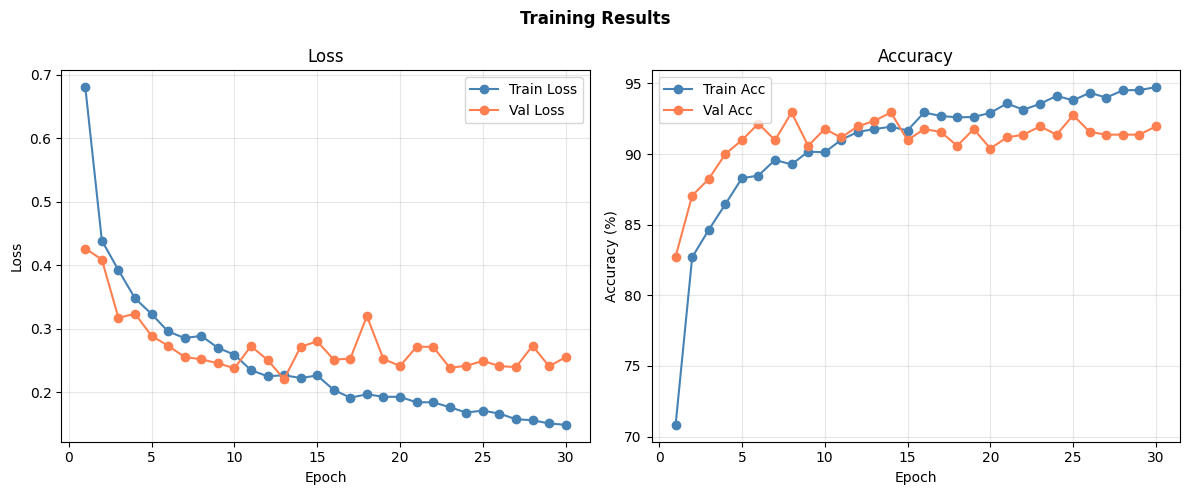

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Training Results", fontweight="bold")

ax1.plot(epochs_range, history['train_loss'], marker='o', label='Train Loss', color='steelblue')
ax1.plot(epochs_range, history['val_loss'],   marker='o', label='Val Loss',   color='coral')
ax1.set_title("Loss");  ax1.set_xlabel("Epoch");  ax1.set_ylabel("Loss")
ax1.legend();  ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], marker='o', label='Train Acc', color='steelblue')
ax2.plot(epochs_range, history['val_acc'],   marker='o', label='Val Acc',   color='coral')
ax2.set_title("Accuracy");  ax2.set_xlabel("Epoch");  ax2.set_ylabel("Accuracy (%)")
ax2.legend();  ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Final Test Evaluation (using best model) ──────────────────
print("Loading best model for final evaluation...")
model.load_state_dict(torch.load(best_checkpoint_path))
model.eval()

correct = 0
total   = 0

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images = images.to(device)
        labels = labels.to(device)

        outputs      = model(images)
        _, predicted = torch.max(outputs, 1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total
print(f"\nFinal Test Accuracy: {test_accuracy:.2f}%")

Loading best model for final evaluation...


Testing: 100%|██████████| 8/8 [00:03<00:00,  2.65it/s]


Final Test Accuracy: 90.00%


Generating predictions: 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]


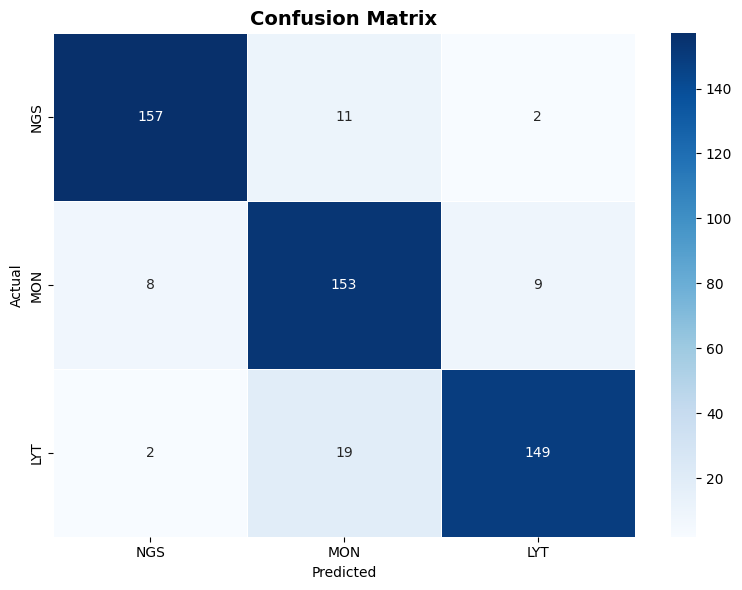


Classification Report:
              precision    recall  f1-score   support

         NGS       0.94      0.92      0.93       170
         MON       0.84      0.90      0.87       170
         LYT       0.93      0.88      0.90       170

    accuracy                           0.90       510
   macro avg       0.90      0.90      0.90       510
weighted avg       0.90      0.90      0.90       510



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Get predictions ───────────────────────────────────────────
model.load_state_dict(torch.load("/content/drive/MyDrive/checkpointsss/vgg16_best.pth", map_location=device))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Generating predictions"):
        images = images.to(device)
        outputs      = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# ── Confusion Matrix ──────────────────────────────────────────
class_names = ['NGS', 'MON', 'LYT']

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

# ── Per-class breakdown ───────────────────────────────────────
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))